# L5 · 바닥판 (외측슬래브) — 왜 캔틸레버가 단면을 정하는가

## 이 시간에 답할 질문

[L4](L4_바닥판설계_내측슬래브.ipynb) 에서 내측슬래브를 풀었다. 같은
다리의 **바깥으로 내민 부분**을 풀면 설계휨모멘트가 **2.1 배**가 된다.
철근도 D16@150 에서 D19@125 로 올라간다.

왜 이렇게 커지는가? 흔한 설명은 두 가지다.

> "방호벽 자중 때문이다."
> "윤하중이 좁은 폭에만 퍼지기 때문이다."

**둘 다 틀렸다.** 이 시간에는 계산으로 그것을 확인하고 진짜 원인을
찾는다.

1. 캔틸레버의 등가 분포폭은 내측보다 넓은가, 좁은가?
2. 방호벽은 증가분의 몇 %를 설명하는가?
3. 그렇다면 무엇이 캔틸레버를 지배하는가?
4. 고정단을 두껍게(헌치) 하는 것은 얼마나 효과가 있는가?
5. 실제 설계에서 캔틸레버 상부철근을 정하는 것은 정말 이 계산인가?

## 근거 조문

| 내용 | 조문 |
|---|---|
| 최외측 차륜 위치 (차도 끝에서 300 mm) | KDS 24 10 11 4.6.2.3(3)⑤ |
| 캔틸레버 등가 분포폭 식 $(4.6\text{-}4)$ | KDS 24 10 11 4.6.2.5 |
| 내측 등가 분포폭 식 $(4.6\text{-}2)$ | KDS 24 10 11 4.6.2.4 |
| 고정하중 휨모멘트 표 4.6-2 (캔틸레버 $-wl^2/2$) | KDS 24 10 11 4.6.2.7 |
| 충격 25 % | KDS 24 12 21 표 4.4-1 |
| 하중조합 극한Ⅰ | KDS 24 12 11 표 4.1-1 |
| 피복두께 식 $(4.4\text{-}1)$, 표 4.4-4 | KDS 24 14 21 4.4.4 |
| 차량 충돌하중 (이 편의 범위 밖) | KDS 24 90 11 |

:::{tip}
같은 내용을 슬라이더로 움직여 보려면
[대화형 탐색기](../_static/explorer.html)를 연다. 값을 바꾸면 그래프가 바로
따라 바뀐다.
:::

## 0. 준비

**아래 코드가 하는 일** — 한글 글꼴을 등록하고 그림 색을 정한다.

In [1]:
%matplotlib inline

import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다."""
    site = Path(sys.prefix, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Malgun Gothic", "AppleGothic",
                 "Noto Sans CJK KR", "Noto Sans KR", "WenQuanYi Zen Hei"):
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    warnings.warn(
        "한글 글꼴을 찾지 못했다. 그림의 한글이 깨진다면 "
        "`pip install koreanize-matplotlib` 로 글꼴만 내려받거나, "
        "나눔고딕·Noto Sans KR 을 시스템에 설치한다.",
        stacklevel=2,
    )
    return None


print("사용 글꼴:", use_korean_font())

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 단면 분류에 쓰는 색 (압축지배 · 변화구간 · 인장지배)
C_COMP, C_TRAN, C_TENS = "#ad3327", "#b5811f", "#2a7355"
BAND = {"압축지배단면": C_COMP, "변화구간단면": C_TRAN, "인장지배단면": C_TENS}

사용 글꼴: NanumGothic


**아래 코드가 하는 일** — 이 편에서 따라갈 설계 흐름을 순서도로
그린다. 각 단계 옆에 근거 조문을 적었다.

/tmp/ipykernel_20017/1136302285.py:77: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.tight_layout()
/tmp/claude-0/-home-user-wkclauderepositoty/78f995f2-8acb-52ee-a7a0-dbb2b3510f36/scratchpad/venv312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


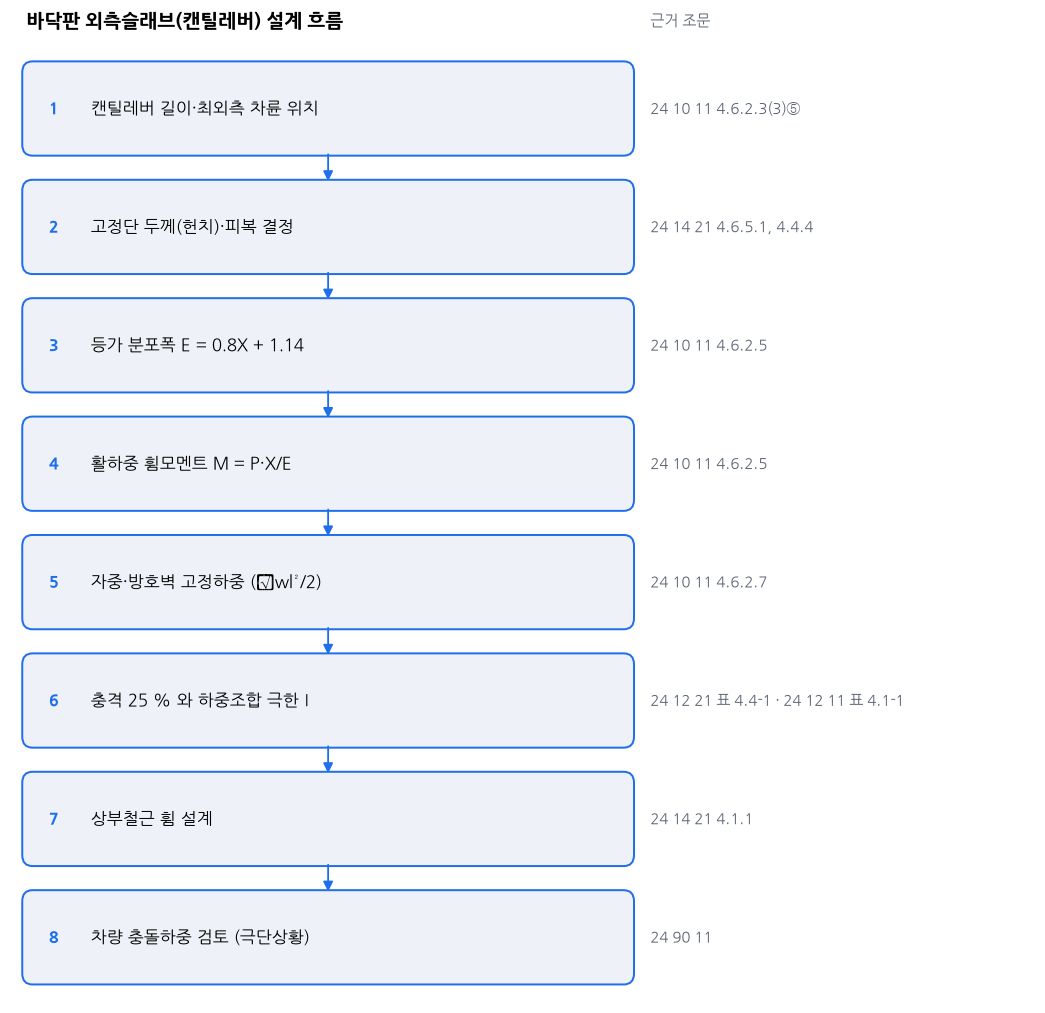

In [2]:
def _use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다.

    예제 노트북의 준비 셀은 축 라벨을 ASCII 로 두므로 글꼴을 등록하지 않는다.
    순서도는 한글을 쓰므로 여기서 직접 챙긴다.
    """
    import glob
    import sys
    from pathlib import Path

    from matplotlib import font_manager

    site = Path(sys.prefix, "lib",
                f"python{sys.version_info.major}.{sys.version_info.minor}",
                "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic"):
        if name in installed:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False


def design_flowchart(title, steps, width=9.6, box_h=0.78, gap=0.30):
    """설계 흐름을 세로 순서도로 그린다.

    Args:
        title: 그림 제목
        steps: (단계 이름, KDS 조문) 튜플의 목록. 조문에 여러 개를 적으려면
            줄바꿈 대신 쉼표로 잇는다.
        width: 그림 폭 (in)
        box_h: 상자 하나의 높이 (in 환산 전 좌표 단위)
        gap: 상자 사이 간격
    """
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

    _use_korean_font()

    n = len(steps)
    fig_h = n * (box_h + gap) + 0.7
    fig, ax = plt.subplots(figsize=(width, fig_h))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n * (box_h + gap) + 0.4)
    ax.axis("off")

    face, edge = "#eef2f8", "#1f6feb"
    for i, (name, clause) in enumerate(steps):
        y = (n - 1 - i) * (box_h + gap) + 0.2
        ax.add_patch(FancyBboxPatch(
            (0.15, y), 5.9, box_h, boxstyle="round,pad=0.04,rounding_size=0.10",
            facecolor=face, edgecolor=edge, linewidth=1.3))
        ax.text(0.42, y + box_h / 2, f"{i + 1}", va="center", ha="center",
                fontsize=10.5, color=edge, fontweight="bold")
        ax.text(0.78, y + box_h / 2, name, va="center", ha="left", fontsize=11)
        ax.text(6.25, y + box_h / 2, clause, va="center", ha="left",
                fontsize=9.5, color="#5d6675")

        if i < n - 1:
            ax.add_patch(FancyArrowPatch(
                (3.1, y), (3.1, y - gap),
                arrowstyle="-|>", mutation_scale=13,
                color=edge, linewidth=1.2))

    ax.text(0.15, n * (box_h + gap) + 0.22, title, fontsize=12.5,
            fontweight="bold", va="bottom")
    ax.text(6.25, n * (box_h + gap) + 0.24, "근거 조문", fontsize=10,
            color="#5d6675", va="bottom")
    fig.tight_layout()
    return fig

design_flowchart(
"바닥판 외측슬래브(캔틸레버) 설계 흐름",
[
    ("캔틸레버 길이·최외측 차륜 위치", "24 10 11 4.6.2.3(3)⑤"),
    ("고정단 두께(헌치)·피복 결정", "24 14 21 4.6.5.1, 4.4.4"),
    ("등가 분포폭 E = 0.8X + 1.14", "24 10 11 4.6.2.5"),
    ("활하중 휨모멘트 M = P·X/E", "24 10 11 4.6.2.5"),
    ("자중·방호벽 고정하중 (−wl²/2)", "24 10 11 4.6.2.7"),
    ("충격 25 % 와 하중조합 극한Ⅰ", "24 12 21 표 4.4-1 · 24 12 11 표 4.1-1"),
    ("상부철근 휨 설계", "24 14 21 4.1.1"),
    ("차량 충돌하중 검토 (극단상황)", "24 90 11"),
],
)
plt.show()

**아래 코드가 하는 일** — 캔틸레버의 하중별 휨모멘트를 구하는 함수를
정의한다. 예제 17 과 같은 교량(캔틸레버 1.3 m, 고정단 280 mm)이다.

In [3]:
from concreteproperties_kds.kds import stress_block_parameters
from concreteproperties_kds.kds24 import (
    COMBINATIONS_BY_NAME,
    WHEEL_LOAD,
    bar_area,
    cantilever_live_load_moment,
    cantilever_wheel_width,
    dead_load_moment,
    design_compressive_strength,
    design_yield_strength,
    equivalent_block,
    impact_factor,
    live_load_moment,
    max_bar_spacing,
    minimum_flexural_steel,
    nominal_cover,
    provided_steel_area,
    required_steel_area,
)

# 기준 조건 — 예제 17 의 교량과 같다
CANTILEVER = 1.30     # 캔틸레버 길이 (m)        ← 바꿔 보라
HAUNCH = 280.0        # 고정단 두께 (mm, 헌치)   ← 바꿔 보라
GIRDER_SPACING = 2.5  # 내측 비교용 거더 간격 (m)
THICKNESS = 240.0     # 내측 바닥판 두께 (mm)
EXPOSURE = "ED1"      # 제설염에 노출               ← 바꿔 보라
PAVEMENT = 80.0       # 포장 두께 (mm)
BARRIER_LOAD = 8.0    # 방호벽 자중 (kN/m)         ← 바꿔 보라
BARRIER_ARM = 0.25    # 방호벽 도심의 끝단 이격 (m)
EDGE_TO_WHEEL = 0.30  # 차도 끝에서 최외측 차륜 (m, 4.6.2.3(3)⑤)
FCK, FY = 27.0, 400.0
GAMMA_C, GAMMA_P = 24.5, 22.5

C_DEAD = "#5b6472"
C_LIVE = "#1f6feb"
C_CAP = "#1f7a4d"
C_K14 = "#b3372c"
C_LOAD = "#b3372c"
C_MUTED = "#5b6472"


def cantilever_moments(x_cant=CANTILEVER, haunch=HAUNCH, barrier=BARRIER_LOAD):
    """캔틸레버 고정단의 하중별 휨모멘트를 돌려준다 (kN·m/m)."""
    x_wheel = x_cant - EDGE_TO_WHEEL
    m_dc = abs(dead_load_moment(w=GAMMA_C * haunch / 1000.0, span=x_cant,
                                kind="캔틸레버판"))
    m_dc += barrier * (x_cant - BARRIER_ARM)
    m_dw = abs(dead_load_moment(w=GAMMA_P * PAVEMENT / 1000.0,
                                span=x_cant - 0.5, kind="캔틸레버판"))
    m_ll = cantilever_live_load_moment(x=x_wheel)
    m_im = m_ll * (impact_factor() - 1.0)
    return {"DC": m_dc, "DW": m_dw, "LL": m_ll, "IM": m_im}


print(f"윤하중 P = {WHEEL_LOAD:.0f} kN,  캔틸레버 {CANTILEVER:.2f} m")
print(f"최외측 차륜 위치 X = {CANTILEVER - EDGE_TO_WHEEL:.2f} m (고정단에서)")

윤하중 P = 96 kN,  캔틸레버 1.30 m
최외측 차륜 위치 X = 1.00 m (고정단에서)


## 1. 분포폭 — 캔틸레버가 정말 좁은가

기준은 내측과 캔틸레버에 **다른 식**을 준다.

$$
\text{내측: } E = 1.2 + 0.06L \le 2.1 \,\text{m}
\qquad
\text{캔틸레버: } E = 0.8X + 1.14 \,\text{m}
$$

$L$ 은 거더 간격, $X$ 는 고정단에서 윤하중까지의 거리다.
직관은 "캔틸레버는 한쪽만 지지되니 힘이 퍼질 데가 없다 → 좁다"고
말한다. 넣어 보자.

**아래 코드가 하는 일** — 두 식을 나란히 계산한다.

In [4]:
x_wheel = CANTILEVER - EDGE_TO_WHEEL
e_can = cantilever_wheel_width(x=x_wheel)
e_int = min(1.2 + 0.06 * GIRDER_SPACING, 2.1)

print(f"내측    L = {GIRDER_SPACING:.2f} m  ->  E = {e_int:.3f} m")
print(f"캔틸레버 X = {x_wheel:.2f} m  ->  E = {e_can:.3f} m")
print()
print(f"캔틸레버의 분포폭이 {e_can / e_int:.2f} 배 '넓다'.")
print()
print(f"{'X (m)':>7} {'캔틸레버 E':>12} | {'L (m)':>7} {'내측 E':>10}")
print("-" * 44)
for v in (0.5, 0.8, 1.0, 1.3, 1.6, 2.0):
    print(f"{v:7.2f} {cantilever_wheel_width(x=v):12.3f} | "
          f"{v:7.2f} {min(1.2 + 0.06 * v, 2.1):10.3f}")

내측    L = 2.50 m  ->  E = 1.350 m
캔틸레버 X = 1.00 m  ->  E = 1.940 m

캔틸레버의 분포폭이 1.44 배 '넓다'.

  X (m)       캔틸레버 E |   L (m)       내측 E
--------------------------------------------
   0.50        1.540 |    0.50      1.230
   0.80        1.780 |    0.80      1.248
   1.00        1.940 |    1.00      1.260
   1.30        2.180 |    1.30      1.278
   1.60        2.420 |    1.60      1.296
   2.00        2.740 |    2.00      1.320


**읽는 법** — 직관이 틀렸다. 캔틸레버의 분포폭이 **1.44 배 넓다.**
게다가 $X$ 에 대한 기울기가 0.8 로, 내측의 0.06 보다 **13 배** 가파르다.

왜 이런가? 두 식이 재는 것이 다르기 때문이다.

- 내측의 $L$ 은 **지간**이다. 지간이 길어져도 윤하중이 퍼지는 폭은
  크게 달라지지 않는다(그래서 기울기가 완만하고 2.1 m 에서 잘린다).
- 캔틸레버의 $X$ 는 **고정단에서 하중까지의 거리**다. 하중이 고정단에서
  멀수록 힘이 부채꼴로 퍼질 여유가 생긴다(그래서 기울기가 가파르다).

분포폭만 보면 캔틸레버가 **유리하다.** 그런데도 모멘트는 크다.

## 2. 그렇다면 무엇이 키우는가

**아래 코드가 하는 일** — 활하중 휨모멘트를 두 식으로 각각 구해
분해한다.

In [5]:
m_ll_int = live_load_moment(span=GIRDER_SPACING, continuous=True)
m_ll_can = cantilever_live_load_moment(x=x_wheel)

print("내측    식 (4.6-1)  M = (L + 0.6) P / 9.6 x 0.8")
print(f"        = ({GIRDER_SPACING} + 0.6) x {WHEEL_LOAD:.0f} / 9.6 "
      f"x 0.8 = {m_ll_int:.2f} kN·m/m")
print()
print("캔틸레버 식 (4.6-4)  M = P x X / E")
print(f"        = {WHEEL_LOAD:.0f} x {x_wheel:.2f} / {e_can:.3f} "
      f"= {m_ll_can:.2f} kN·m/m")
print()
print(f"활하중만으로 이미 {m_ll_can / m_ll_int:.2f} 배다.")
print()
# 연속 0.8 배 혜택이 없다면 내측은 얼마였을까
m_ll_int_simple = live_load_moment(span=GIRDER_SPACING, continuous=False)
print(f"내측이 단순판이었다면      {m_ll_int_simple:.2f} kN·m/m")
print(f"연속판이라 0.8 배를 받아  {m_ll_int:.2f} kN·m/m")
print(f"  -> 연속 혜택만으로 {(1 - 0.8) * 100:.0f} % 를 덜어낸다.")

내측    식 (4.6-1)  M = (L + 0.6) P / 9.6 x 0.8
        = (2.5 + 0.6) x 96 / 9.6 x 0.8 = 24.80 kN·m/m

캔틸레버 식 (4.6-4)  M = P x X / E
        = 96 x 1.00 / 1.940 = 49.48 kN·m/m

활하중만으로 이미 2.00 배다.

내측이 단순판이었다면      31.00 kN·m/m
연속판이라 0.8 배를 받아  24.80 kN·m/m
  -> 연속 혜택만으로 20 % 를 덜어낸다.


**읽는 법** — 활하중만으로 벌써 2.00 배다. 그 차이 24.7 kN·m/m 를
갈라 보면 이렇다.

- **연속판 0.8 배 혜택의 부재**: 6.2 (**25 %**). 캔틸레버는 한쪽만
  고정된 외팔보라 모멘트를 나눠 가질 이웃 경간이 없다.
- **지렛대 팔과 식 자체의 차이**: 18.5 (**75 %**). 내측은 윤하중이
  지간 어디에 놓이든 $(L+0.6)/9.6$ 이라는 완만한 계수로 들어가지만,
  캔틸레버는 $P \cdot X$ 가 그대로 고정단에 걸린다.

즉 **주된 원인은 지렛대 팔이고, 연속 혜택은 그 다음**이다.

**아래 코드가 하는 일** — 방호벽이 정말 주범인지 확인한다. 방호벽을
빼고 다시 계산해 본다.

In [6]:
base = cantilever_moments()
no_barrier = cantilever_moments(barrier=0.0)

m_ed = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=base)
m_ed_nb = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=no_barrier)

# 내측부 (L4 와 같은 조건)
w_dc_i = GAMMA_C * THICKNESS / 1000.0
w_dw_i = GAMMA_P * PAVEMENT / 1000.0
loads_int = {
    "DC": abs(dead_load_moment(w=w_dc_i, span=GIRDER_SPACING,
                               kind="연속판_지간")),
    "DW": abs(dead_load_moment(w=w_dw_i, span=GIRDER_SPACING,
                               kind="연속판_지간")),
    "LL": m_ll_int,
    "IM": m_ll_int * (impact_factor() - 1.0),
}
m_ed_int = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=loads_int)

print(f"내측부        M_Ed = {m_ed_int:7.2f} kN·m/m")
print(f"캔틸레버      M_Ed = {m_ed:7.2f} kN·m/m"
      f"   ({m_ed / m_ed_int:.2f} 배)")
print(f"방호벽 없다면 M_Ed = {m_ed_nb:7.2f} kN·m/m")
print()
grow = m_ed - m_ed_int
by_barrier = m_ed - m_ed_nb
print(f"증가분 {grow:.1f} kN·m/m 중")
print(f"  방호벽이 설명하는 몫 {by_barrier:.1f} "
      f"({by_barrier / grow * 100:.0f} %)")
print(f"  나머지               {grow - by_barrier:.1f} "
      f"({(grow - by_barrier) / grow * 100:.0f} %)")

내측부        M_Ed =   62.08 kN·m/m
캔틸레버      M_Ed =  129.95 kN·m/m   (2.09 배)
방호벽 없다면 M_Ed =  119.45 kN·m/m

증가분 67.9 kN·m/m 중
  방호벽이 설명하는 몫 10.5 (15 %)
  나머지               57.4 (85 %)


**읽는 법** — 방호벽이 설명하는 몫은 **15 %** 뿐이다. 나머지 85 % 는
활하중이다. "방호벽 때문"이라는 설명은 크기를 한참 잘못 짚은 것이다.

정리하면 캔틸레버가 커지는 이유는 이 순서다.

1. **지렛대 팔** $P \cdot X$ 가 고정단에 그대로 걸린다 (활하중 차이의 75 %)
2. **연속판의 0.8 배 혜택이 없다** — 외팔보에는 재분배할 이웃이 없다 (25 %)
3. 방호벽 자중 — 전체 증가분의 15 % 로, 작지만 있다

그리고 **분포폭은 오히려 유리하게 작용하고 있다.** 캔틸레버 식이
1.94 m 로 퍼뜨려 주지 않았다면 모멘트는 훨씬 컸을 것이다.

**아래 코드가 하는 일** — 세 성분의 기여를 막대로 그린다.

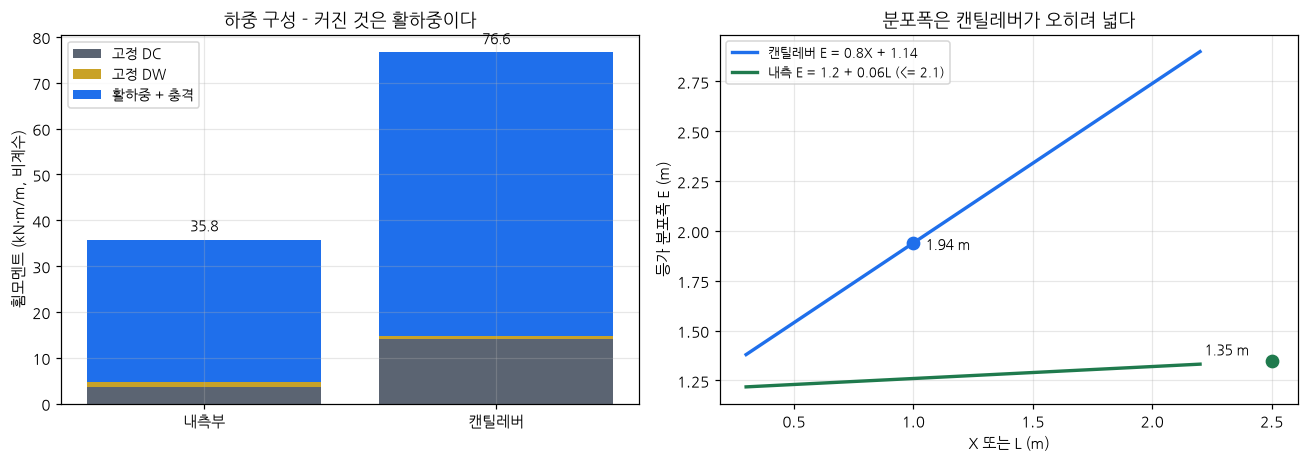

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

# 왼쪽 — 하중 구성 비교
names = ["내측부", "캔틸레버"]
dc = [loads_int["DC"], base["DC"]]
dw = [loads_int["DW"], base["DW"]]
ll = [loads_int["LL"] + loads_int["IM"], base["LL"] + base["IM"]]

ax1.bar(names, dc, color=C_DEAD, label="고정 DC")
ax1.bar(names, dw, bottom=dc, color="#c9a227", label="고정 DW")
ax1.bar(names, ll, bottom=[a + b for a, b in zip(dc, dw)],
        color=C_LIVE, label="활하중 + 충격")
for i, (a, b, c) in enumerate(zip(dc, dw, ll)):
    ax1.text(i, a + b + c + 2, f"{a + b + c:.1f}", ha="center",
             fontsize=9)
ax1.set_ylabel("휨모멘트 (kN·m/m, 비계수)")
ax1.set_title("하중 구성 - 커진 것은 활하중이다")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# 오른쪽 — 분포폭
xs = np.linspace(0.3, 2.2, 100)
ax2.plot(xs, 0.8 * xs + 1.14, color=C_LIVE, lw=2.2,
         label="캔틸레버 E = 0.8X + 1.14")
ax2.plot(xs, np.minimum(1.2 + 0.06 * xs, 2.1), color=C_CAP, lw=2.2,
         label="내측 E = 1.2 + 0.06L (<= 2.1)")
ax2.plot([x_wheel], [e_can], "o", color=C_LIVE, ms=8)
ax2.plot([GIRDER_SPACING], [e_int], "o", color=C_CAP, ms=8)
ax2.annotate(f"{e_can:.2f} m", (x_wheel, e_can),
             textcoords="offset points", xytext=(8, -4), fontsize=9)
ax2.annotate(f"{e_int:.2f} m", (GIRDER_SPACING, e_int),
             textcoords="offset points", xytext=(-44, 4), fontsize=9)
ax2.set_xlabel("X 또는 L (m)")
ax2.set_ylabel("등가 분포폭 E (m)")
ax2.set_title("분포폭은 캔틸레버가 오히려 넓다")
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 3. 헌치 — 고정단을 두껍게 하면

캔틸레버는 고정단에서 모멘트가 최대이고 끝으로 갈수록 0 이다. 그래서
고정단만 두껍게 하는 **헌치**가 자연스럽다. 얼마나 듣는가?

**아래 코드가 하는 일** — 고정단 두께를 바꿔 가며 소요 철근량과
설계휨강도를 본다.

In [8]:
def cantilever_design(haunch, dia=19.0, spacing=125.0):
    """고정단 두께에 대한 소요·배치 철근량과 강도를 돌려준다."""
    loads = cantilever_moments(haunch=haunch)
    m_ed = COMBINATIONS_BY_NAME["극한Ⅰ"].evaluate(loads=loads)
    _, cover = nominal_cover(exposure=EXPOSURE, bar_diameter=dia)
    d = haunch - cover - dia / 2
    as_req = required_steel_area(m_ed=m_ed * 1e6, d=d, fck=FCK, fy=FY)
    as_prov = provided_steel_area(diameter=dia, spacing=spacing)
    f_cd = design_compressive_strength(fck=FCK)
    f_yd = design_yield_strength(fy=FY)
    alpha, beta = equivalent_block(fck=FCK)
    c = as_prov * f_yd / (alpha * f_cd * 1000.0)
    m_rd = as_prov * f_yd * (d - beta * c) / 1e6
    return m_ed, d, as_req, as_prov, m_rd

print(f"{'헌치':>7} {'d':>7} {'M_Ed':>8} {'필요 As':>9} "
      f"{'M_Rd':>8} {'M_Rd/M_Ed':>10}")
print("-" * 56)
for h in (240.0, 260.0, 280.0, 300.0, 350.0, 400.0):
    m_ed_h, d_h, as_req, as_prov, m_rd = cantilever_design(h)
    print(f"{h:7.0f} {d_h:7.0f} {m_ed_h:8.1f} {as_req:9.0f} "
          f"{m_rd:8.1f} {m_rd / m_ed_h:10.2f}")

     헌치       d     M_Ed     필요 As     M_Rd  M_Rd/M_Ed
--------------------------------------------------------
    240     176    128.9      2475    120.2       0.93
    260     196    129.4      2127    136.6       1.06
    280     216    130.0      1879    152.9       1.18
    300     236    130.5      1690    169.2       1.30
    350     286    131.8      1363    210.1       1.59
    400     336    133.1      1151    250.9       1.89


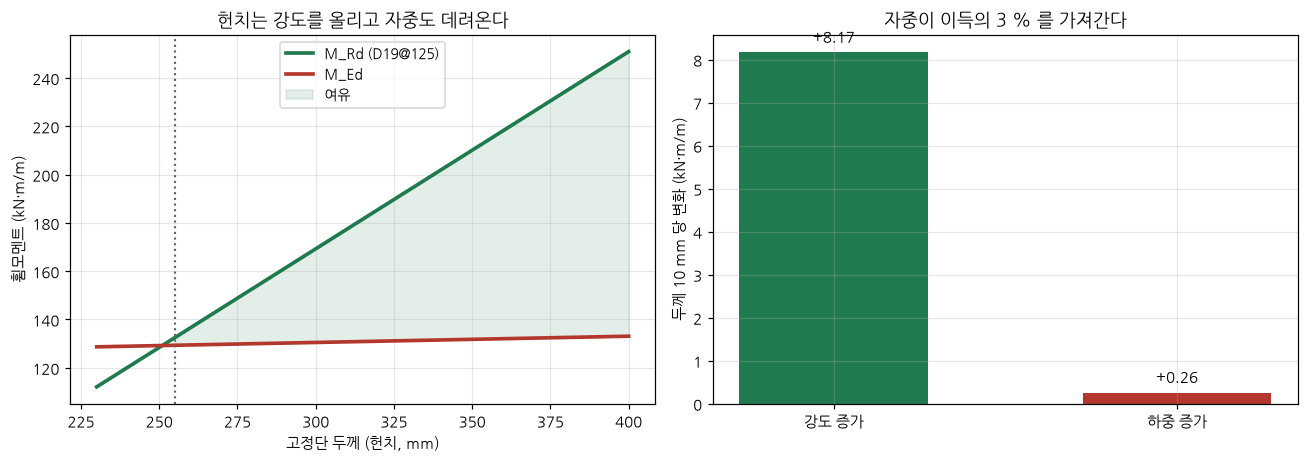

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

hs = np.arange(230.0, 405.0, 5.0)
med = np.array([cantilever_design(float(h))[0] for h in hs])
mrd = np.array([cantilever_design(float(h))[4] for h in hs])

ax1.plot(hs, mrd, color=C_CAP, lw=2.4, label="M_Rd (D19@125)")
ax1.plot(hs, med, color=C_LOAD, lw=2.4, label="M_Ed")
ax1.fill_between(hs, med, mrd, where=(mrd >= med), color=C_CAP,
                 alpha=0.12, label="여유")
idx = int(np.argmax(mrd >= med))
if mrd[idx] >= med[idx]:
    ax1.axvline(hs[idx], color=C_MUTED, ls=":", lw=1.4)
    ax1.annotate(f"{hs[idx]:.0f} mm 부터 만족",
                 (hs[idx], mrd.max() * 0.35), ha="center",
                 fontsize=9, color=C_MUTED)
ax1.set_xlabel("고정단 두께 (헌치, mm)")
ax1.set_ylabel("휨모멘트 (kN·m/m)")
ax1.set_title("헌치는 강도를 올리고 자중도 데려온다")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

gain = (mrd[-1] - mrd[0]) / (hs[-1] - hs[0]) * 10
cost = (med[-1] - med[0]) / (hs[-1] - hs[0]) * 10
ax2.bar(["강도 증가", "하중 증가"], [gain, cost],
        color=[C_CAP, C_LOAD], width=0.55)
for i2, v in enumerate([gain, cost]):
    ax2.text(i2, v + gain * 0.03, f"{v:+.2f}", ha="center", fontsize=10)
ax2.set_ylabel("두께 10 mm 당 변화 (kN·m/m)")
ax2.set_title(f"자중이 이득의 {cost / gain * 100:.0f} % 를 가져간다")
ax2.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

**읽는 법** — 헌치는 **두 방향으로 동시에 듣는다.** 두께가 늘면
$d$ 가 커져 강도가 오르고, 동시에 자중이 늘어 $M_{Ed}$ 도 오른다.
L4 의 내측슬래브에서는 자중이 이득의 4 % 만 갉아먹었는데, 캔틸레버는
자중이 $-wl^2/2$ 로 걸려 **더 많이** 갉아먹는다.

그래도 순효과는 뚜렷하다. 헌치가 캔틸레버 설계의 표준 수단인 이유다.

## 4. 철근 배치 — 위쪽이다

내측슬래브는 지간부에서 아래가 인장이라 **하부철근**이 주철근이었다.
캔틸레버는 고정단에서 **위가 인장**이므로 **상부철근**이 주철근이다.

이 철근은 바닥판 상면 가까이 놓이는데, 그 위가 바로 **제설염이 닿는
면**이다. 그래서 노출등급이 피복을 크게 밀어올린다.

**아래 코드가 하는 일** — 노출등급별 피복과 그 대가를 본다.

In [10]:
print(f"{'노출등급':>8} {'피복':>7} {'d':>7} {'M_Rd':>9} {'M_Rd/M_Ed':>10}")
print("-" * 46)
for cls in ("E0", "EC1", "EC2", "ED1", "ED3", "ES3"):
    _, cover = nominal_cover(exposure=cls, bar_diameter=19.0)
    d = HAUNCH - cover - 19.0 / 2
    as_prov = provided_steel_area(diameter=19.0, spacing=125.0)
    f_cd = design_compressive_strength(fck=FCK)
    f_yd = design_yield_strength(fy=FY)
    alpha, beta = equivalent_block(fck=FCK)
    c = as_prov * f_yd / (alpha * f_cd * 1000.0)
    m_rd = as_prov * f_yd * (d - beta * c) / 1e6
    mark = "  <- 이 강의" if cls == EXPOSURE else ""
    print(f"{cls:>8} {cover:7.0f} {d:7.0f} {m_rd:9.1f} "
          f"{m_rd / m_ed:10.2f}{mark}")

    노출등급      피복       d      M_Rd  M_Rd/M_Ed
----------------------------------------------
      E0      30     240     173.3       1.33
     EC1      35     236     169.2       1.30
     EC2      45     226     161.1       1.24
     ED1      55     216     152.9       1.18  <- 이 강의
     ED3      65     206     144.7       1.11
     ES3      80     190     132.5       1.02


## 5. 그런데 실제로는 무엇이 상부철근을 정하는가

여기까지 캔틸레버를 **활하중과 자중**으로 풀었다. 그런데 실무에서
캔틸레버 상부철근은 대개 이 계산으로 정해지지 않는다.

**차량 충돌하중**(KDS 24 90 11) 때문이다. 방호벽에 차량이 부딪히면
그 힘이 캔틸레버 고정단에 모멘트로 전달되는데, 이것은
**극단상황한계상태**로 검토한다. 등급에 따라 수백 kN 의 횡력이
방호벽 상단에 걸리므로, 고정단 모멘트가 이 강의의 130 kN·m/m 를
크게 넘는 경우가 많다.

> **설계의 의도** — 이 강의가 푼 것은 **하한**이다. 충돌하중은
> 극단상황이라 하중계수와 검토 방식이 다르고, 방호벽-바닥판 접합부의
> 상세가 함께 결정된다. 이 편의 범위 밖이지만, **캔틸레버 상부철근을
> 활하중만으로 확정해서는 안 된다**는 것은 기억해야 한다.

**아래 코드가 하는 일** — 참고로, 방호벽 상단에 횡력이 걸릴 때
고정단 모멘트가 어떻게 자라는지 크기만 가늠해 본다.

In [11]:
# 방호벽 높이 (m) 와 가상의 횡력 — 실제 값은 KDS 24 90 11 의 등급을 따른다
H_BARRIER = 1.27
print("참고 — 방호벽 상단 횡력이 고정단에 만드는 모멘트")
print(f"{'횡력 (kN/m)':>12} {'M (kN·m/m)':>12} {'활하중 M_Ed 대비':>16}")
print("-" * 44)
for ft in (20.0, 50.0, 100.0, 150.0):
    m_collision = ft * H_BARRIER
    print(f"{ft:12.0f} {m_collision:12.1f} "
          f"{m_collision / m_ed:15.2f} 배")
print()
print("실제 검토는 극단상황한계상태 하중조합과 방호벽 자체의 저항")
print("(항복선 이론)까지 함께 보아야 한다. KDS 24 90 11 을 볼 것.")

참고 — 방호벽 상단 횡력이 고정단에 만드는 모멘트
   횡력 (kN/m)   M (kN·m/m)      활하중 M_Ed 대비
--------------------------------------------
          20         25.4            0.20 배
          50         63.5            0.49 배
         100        127.0            0.98 배
         150        190.5            1.47 배

실제 검토는 극단상황한계상태 하중조합과 방호벽 자체의 저항
(항복선 이론)까지 함께 보아야 한다. KDS 24 90 11 을 볼 것.


## 6. 바꿔 보며 확인할 것

1. `CANTILEVER` 를 0.8 m 로 줄이면 내측부와 어느 쪽이 지배하는가?
   캔틸레버가 짧아지면 분포폭도 좁아진다는 점을 함께 보라.
2. `BARRIER_LOAD` 를 두 배로 올리면 $M_{Ed}$ 가 몇 % 오르는가?
   방호벽이 주범이 아니라는 결론이 유지되는가?
3. `HAUNCH` 를 240 mm(내측과 같게)로 두면 D19@125 로 충분한가?
4. 노출등급을 `ES3` 로 바꾸면 헌치를 얼마나 키워야 원래 강도를
   되찾는가?

## 7. 정리

1. **캔틸레버의 등가 분포폭은 내측보다 넓다** (1.94 vs 1.35 m).
   "좁은 폭에 몰린다"는 설명은 틀렸다. $X$ 에 대한 기울기가 0.8 로
   내측의 0.06 보다 13 배 가파른데, 두 식이 재는 것이 다르기 때문이다.
2. **방호벽은 주범이 아니다.** 증가분의 대부분은 활하중이다.
3. **진짜 원인은 지렛대 팔(75 %)과 연속 혜택의 부재(25 %)다.**
   방호벽은 전체 증가분의 15 % 에 그친다.
4. **헌치는 듣지만 자중을 데려온다.** 캔틸레버는 자중이 $-wl^2/2$ 로
   걸려 내측보다 대가가 크다.
5. **주철근은 상부철근이고, 그 위가 제설염이 닿는 면이다.**
   노출등급이 피복을 통해 강도를 직접 깎는다.
6. **이 계산은 하한이다.** 실제 캔틸레버 상부철근은 차량 충돌하중
   (KDS 24 90 11, 극단상황한계상태)이 정하는 경우가 많다.

## 8. 생각해 볼 문제

1. 캔틸레버 분포폭 식의 기울기가 0.8 로 가파른데, $X$ 가 0 에 가까워지면
   $E \to 1.14$ m 로 수렴한다. 이 1.14 m 는 무엇을 뜻하는가?
2. 캔틸레버를 길게 하면 활하중 모멘트는 $P X / (0.8X + 1.14)$ 로
   자란다. $X$ 가 매우 커지면 이 값은 어디로 수렴하는가? 그 극한값이
   설계에 시사하는 바는?
3. 내측슬래브는 연속판이라 0.8 배를 받는다. 그런데 **최외측 거더 위**의
   단면은 한쪽은 캔틸레버, 한쪽은 내측 경간이다. 이 지점의 부모멘트는
   어느 쪽 규정을 따라야 하는가?
4. 헌치를 키우는 대신 캔틸레버를 짧게 하고 거더를 하나 더 놓는 방법도
   있다. 두 선택의 대가를 무엇으로 견주어야 하는가?
5. 충돌하중이 상부철근을 정한다면, 이 강의가 푼 활하중 검토는 무의미한가?
   그렇지 않다면 어떤 역할을 하는가?